In [19]:
import pandas as pd
import nltk
from nltk.stem import PorterStemmer


# Data exploratory

In [2]:
df_drug_review= pd.read_csv('drugsComTrain_raw.csv')
df_drug_review.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [3]:
df_drug_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161297 entries, 0 to 161296
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   uniqueID     161297 non-null  int64 
 1   drugName     161297 non-null  object
 2   condition    160398 non-null  object
 3   review       161297 non-null  object
 4   rating       161297 non-null  int64 
 5   date         161297 non-null  object
 6   usefulCount  161297 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 8.6+ MB


## Explanation of the variables

The structure of the dataset is that each patient meeting a condition write a review and a rating for the drug he purchased on the date. 

the dataset has 7 columns including the index. The six columns are: 
 - uniqueID (categorical) : it correponds to the Id number of the rewiew
 - drugName (categorical) : name of the drug
 - condition (text): name of condition
 - review (text): Patient review
 - rating(numeric): 10 star patient rating  
 - date (date): date of review entry
 - useful count(numeric): number of users who found review useful

 The useful variables are : DrugName,condition, review, rating and useful count. 

In [4]:
df_drug_review.shape

(161297, 7)

In [5]:
df_drug_review.nunique()

uniqueID       161297
drugName         3436
condition         884
review         112329
rating             10
date             3579
usefulCount       389
dtype: int64

The dataframe count 161 297 entries : There is 3436 differents drugs which received a review from patient. 

In [6]:
df_drug_review.describe(include="all")

,uniqueID,drugName,condition,review,rating,date,usefulCount
count,161297.000000,161297,160398,161297,161297.000000,161297,161297.000000
unique,NaN,3436,884,112329,NaN,3579,NaN
top,NaN,Levonorgestrel,Birth Control,"""Good""",NaN,1-Mar-16,NaN
freq,NaN,3657,28788,33,NaN,146,NaN
mean,115923.585305,NaN,NaN,NaN,6.994377,NaN,28.004755
std,67004.445170,NaN,NaN,NaN,3.272329,NaN,36.403742
min,2.000000,NaN,NaN,NaN,1.000000,NaN,0.000000
25%,58063.000000,NaN,NaN,NaN,5.000000,NaN,6.000000
50%,115744.000000,NaN,NaN,NaN,8.000000,NaN,16.000000
75%,173776.000000,NaN,NaN,NaN,10.000000,NaN,36.000000


### 1) Missing values: 

How many values are misisng for each variables ? 

In [7]:
#cheking missing values
null_values = df_drug_review.isnull().sum()
missing_percent= df_drug_review.isnull().sum()/len(df_drug_review)*100
missing_table=pd.DataFrame({"missing_values":null_values, "percent": missing_percent})
missing_table = missing_table[missing_table["missing_values"] > 0].sort_values(by="percent", ascending=False)

print(missing_table)

           missing_values   percent
condition             899  0.557357


We can see that the variable "condition" misses 899 values or 0.55% of the total. It's not really an issue. If needed, will delete theses values in the study. 

In [8]:
#checking of duplicates
df_drug_review.duplicated().sum()

np.int64(0)

### 2)Cleaning of the column 'condition'

In [9]:
#counting and listing the conditions for the reviews.
condition_review=df_drug_review['condition'].value_counts()
print(condition_review.head(50))

condition
Birth Control                   28788
Depression                       9069
Pain                             6145
Anxiety                          5904
Acne                             5588
Bipolar Disorde                  4224
Insomnia                         3673
Weight Loss                      3609
Obesity                          3568
ADHD                             3383
Diabetes, Type 2                 2554
Emergency Contraception          2463
High Blood Pressure              2321
Vaginal Yeast Infection          2274
Abnormal Uterine Bleeding        2096
Bowel Preparation                1859
ibromyalgia                      1791
Smoking Cessation                1780
Migraine                         1694
Anxiety and Stress               1663
Major Depressive Disorde         1607
Constipation                     1595
Panic Disorde                    1463
Chronic Pain                     1455
Migraine Prevention              1413
Urinary Tract Infection          1316
Mu

In [10]:
#suspicious conditions: contains span, symbols or numbers.
suspect_conditons= df_drug_review[df_drug_review['condition'].str.contains(r'\d|</?span>|<|>', na=False)]
#suspect_conditons['condition'].nunique()
suspect_conditons.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
50,156544,Dulaglutide,"Diabetes, Type 2","""Hey Guys, It&#039;s been 4 months since my l...",10,24-Oct-17,24
105,220696,Loestrin 24 Fe,2</span> users found this comment helpful.,"""I&#039;m 16 and I have been on Loestrin 24 f...",3,3-Nov-10,2
146,156730,Dulaglutide,"Diabetes, Type 2","""I was recently referred to a endocrinologist ...",9,5-Nov-15,12
168,26916,Insulin degludec,"Diabetes, Type 1","""My Endo insisted I switch from lantus to tres...",1,1-May-17,12
182,82188,Liraglutide,"Diabetes, Type 2","""have only been on victorza for a few days. I...",5,28-Jan-16,18


<span style="font-size:15px; line-height:1.6">The variable **`condition`** contains some suspicious conditons which are not helpful to use this variable. Those are mainly **HTML text**. It's possible to clean those conditions or delete them if it's not  concerning a lot of entries on 'conditions'. This can be do by implmenting a function which will: replace any strings containing '/span>', symbol or number by a null value. 
We can see that there is also some unwanted special characters like **'&#'** in the review. For now it's not really important for the treatment so we will let it as it was. 
<br><br>
⚠️ We also noticed some unwanted special characters like '&#' in the reviews.
For now, this is **not important for the current analysis**, so we will **leave it as is**.</span>


In [11]:
import re

def clean_condition(df, colname):

    pattern_counter= re.compile(r'\d+\s*(?:</span?>\s*users?(?:\s+found.*?(?:helpful))?\s*\.{0,3})',re.IGNORECASE)
    def clean_one(t):
        if isinstance(t,str):
            #delete the counter
            t= re.sub(pattern_counter, "",t)
            #delete elipsis   left
            t= re.sub(r'\.\.\.',"",t)
            #delete aditionnal space and trim
            t=re.sub(r'\s+',' ',t).strip()

        return t

    df[colname]= df[colname].apply(clean_one)

    return df


In [12]:
df_condition_cleaned=clean_condition(df_drug_review,'condition')

In [13]:
df_condition_cleaned['condition'].nunique()

812

In [14]:
#suspicious conditions: contains span, symbols or numbers.
suspect_conditons_clean= df_condition_cleaned[df_condition_cleaned['condition'].str.contains(r'\d|</?span>|<|>', na=False)]
suspect_conditons_clean['condition'].nunique()
suspect_conditons_clean.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
50,156544,Dulaglutide,"Diabetes, Type 2","""Hey Guys, It&#039;s been 4 months since my l...",10,24-Oct-17,24
146,156730,Dulaglutide,"Diabetes, Type 2","""I was recently referred to a endocrinologist ...",9,5-Nov-15,12
168,26916,Insulin degludec,"Diabetes, Type 1","""My Endo insisted I switch from lantus to tres...",1,1-May-17,12
182,82188,Liraglutide,"Diabetes, Type 2","""have only been on victorza for a few days. I...",5,28-Jan-16,18
187,32822,Empagliflozin,"Diabetes, Type 2","""I have been taking Jardiance for just over a ...",10,6-Jan-17,47


In [15]:
#checklist for the condition column.
def full_check(df, colname):
    """Checklist complète de validation"""

    checks = {
        'Balises HTML': r'<[^>]+>',
        'Chiffres + users': r'\d+\s*users?',
        'Points de suspension': r'\.\.\.',
        'Espaces multiples': r'\s{2,}',
        'Caractères spéciaux HTML': r'&[a-z]+;',
        'Chiffres isolés': r'\b\d+\b'
    }

    print(f"=== Checklist '{colname}' ===\n")

    all_clean = True
    for name, pattern in checks.items():
        count = df[colname].str.contains(pattern, na=False, regex=True).sum()
        status = "✅" if count == 0 else "❌"
        print(f"{status} {name:25} : {count}")
        if count > 0:
            all_clean = False
            # Afficher exemples
            examples = df[df[colname].str.contains(pattern, na=False, regex=True)][colname].head(3)
            for ex in examples:
                print(f"     → {ex}")

    return all_clean

# Utilisation
full_check(df_condition_cleaned, 'condition')

=== Checklist 'condition' ===

✅ Balises HTML              : 0
✅ Chiffres + users          : 0
✅ Points de suspension      : 0
✅ Espaces multiples         : 0
✅ Caractères spéciaux HTML  : 0
❌ Chiffres isolés           : 2698
     → Diabetes, Type 2
     → Diabetes, Type 2
     → Diabetes, Type 1


False

## Indentifying categories in condition 

In [16]:
#Counting the values of top 50 conditions
condition_count= df_condition_cleaned['condition'].value_counts()
print(condition_count.head(50))


condition
Birth Control                  28788
Depression                      9069
Pain                            6145
Anxiety                         5904
Acne                            5588
Bipolar Disorde                 4224
Insomnia                        3673
Weight Loss                     3609
Obesity                         3568
ADHD                            3383
Diabetes, Type 2                2554
Emergency Contraception         2463
High Blood Pressure             2321
Vaginal Yeast Infection         2274
Abnormal Uterine Bleeding       2096
Bowel Preparation               1859
ibromyalgia                     1791
Smoking Cessation               1780
Migraine                        1694
Anxiety and Stress              1663
Major Depressive Disorde        1607
Constipation                    1595
Panic Disorde                   1463
Chronic Pain                    1455
Migraine Prevention             1413
Urinary Tract Infection         1316
Muscle Spasm                

In [17]:
#identifying variants
pain_condition=df_condition_cleaned[df_condition_cleaned['condition'].str.contains('pain',case=False,na=False)]['condition'].unique()
print(pain_condition)

['Pain' 'Chronic Pain' 'Breakthrough Pain' 'Neuropathic Pain'
 'Period Pain' 'Back Pain' 'Pain/Feve' 'Labor Pain' 'Muscle Pain'
 'Postoperative Pain' 'Chronic Myofascial Pain' 'm Pain Disorde'
 'Postpartum Breast Pain' 'Neck Pain' 'Somatoform Pain Disorde'
 'Manscaping Pain']


For the example "pain' we can see that it exists a lots variants. Here our goal is to apply a large analysis , In other words we don't need more than 20-40 categories. To find these categories we can use NLP technics such as Stemming to reach our goal. 

In [ ]:
import nltk
nltk.download()

#initialiazing Pyhton porter stemmer
ps=PorterStemmer()

#tokennisation

#application to stemmer

for condition in pain_condition:
    words = nltk.word_tokenize(str(condition).lower())
    stems=[ps.stem(word) for word in words]

    print(f"{condition:<30}{', '.join(stems):<30}")


showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml
Pain                          pain                          
Chronic Pain                  chronic, pain                 
Breakthrough Pain             breakthrough, pain            
Neuropathic Pain              neuropath, pain               
Period Pain                   period, pain                  
Back Pain                     back, pain                    
Pain/Feve                     pain/fev                      
Labor Pain                    labor, pain                   
Muscle Pain                   muscl, pain                   
Postoperative Pain            postop, pain                  
Chronic Myofascial Pain       chronic, myofasci, pain       
m Pain Disorde                m, pain, disord               
Postpartum Breast Pain        postpartum, breast, pain      
Neck Pain                     neck, pain                    
Somatoform Pain Disorde       somatoform, pain, disord      
Mans

In [ ]:
# Assurez-vous d'avoir téléchargé 'punkt' si vous ne l'avez pas déjà fait
# nltk.download('punkt')

ps = PorterStemmer()

def get_frequent_stems(condition_series):
    """Calcule et retourne les 50 racines de mots les plus fréquentes dans les conditions."""
    stems = {}

    # Travaillez sur les conditions uniques et non-NaN de votre DataFrame
    unique_conditions = condition_series.dropna().unique()

    for condition in unique_conditions:
        # 1. Tokenisation et mise en minuscule
        words = nltk.word_tokenize(str(condition).lower())
        for word in words:
            # 2. Application du Stemmer
            stem = ps.stem(word)
            stems[stem] = stems.get(stem, 0) + 1

    stems_series = pd.Series(stems).sort_values(ascending=False)

    # Filtrer les mots très courants/peu utiles
    common_stems_to_remove = ['syndrom', 'disord', 'treat', 'condit', 'diseas', 'with', 'and', 'for', 'of', 'in', ',']
    stems_series = stems_series[~stems_series.index.isin(common_stems_to_remove)]

    return stems_series.head(50)

# -------------------------------------------------------------
# 1. Exécutez cette ligne :
frequent_stems = get_frequent_stems(df_condition_cleaned['condition'])

print("--- 50 Racines les plus fréquentes pour construire le dictionnaire ---")
print(frequent_stems)


--- 50 Racines les plus fréquentes pour construire le dictionnaire ---
prophylaxi      32
infect          27
's              27
)               16
pain            15
canc            15
prevent         14
chronic         13
defici          12
acut            10
/               10
(                9
skin             8
thrombosi        8
ulcer            8
leukemia         8
breast           7
bacteri          7
diabet           7
herp             7
deep             7
cell             7
vein             7
hepat            6
ulc              6
constip          6
anemia           6
arthriti         6
diarrhea         6
anxieti          6
lymphoma         6
tinea            6
dermat           6
coliti           6
min              5
event            5
mainten          5
heart            5
type             5
esophag          5
primari          5
depress          5
nausea/vomit     5
neuralgia        5
pneumonia        5
urinari          5
tissu            5
ventricular      5
bowel            

In [ ]:
important_roots = ['pain', 'depress', 'anxiety', 'diabet', 'acn', 'hyperten']

for root in important_roots:
    # Utiliser la racine comme mot-clé pour extraire les conditions complètes
    variants = df_condition_cleaned[df_condition_cleaned['condition'].str.contains(root, case=False, na=False)]['condition'].unique()

    print(f"\n--- VARIANTES TROUVÉES POUR LA RACINE '{root.upper()}' ({len(variants)} uniques) ---")
    # Afficher les variantes triées pour faciliter l'analyse
    print(sorted(variants))



--- VARIANTES TROUVÉES POUR LA RACINE 'PAIN' (16 uniques) ---
['Back Pain', 'Breakthrough Pain', 'Chronic Myofascial Pain', 'Chronic Pain', 'Labor Pain', 'Manscaping Pain', 'Muscle Pain', 'Neck Pain', 'Neuropathic Pain', 'Pain', 'Pain/Feve', 'Period Pain', 'Postoperative Pain', 'Postpartum Breast Pain', 'Somatoform Pain Disorde', 'm Pain Disorde']

--- VARIANTES TROUVÉES POUR LA RACINE 'DEPRESS' (5 uniques) ---
['Depression', 'Major Depressive Disorde', 'Neurotic Depression', 'Persistent Depressive Disorde', 'Postpartum Depression']

--- VARIANTES TROUVÉES POUR LA RACINE 'ANXIETY' (6 uniques) ---
['Anxiety', 'Anxiety and Stress', 'Generalized Anxiety Disorde', 'Performance Anxiety', 'Social Anxiety Disorde', 'mance Anxiety']

--- VARIANTES TROUVÉES POUR LA RACINE 'DIABET' (7 uniques) ---
['Diabetes Insipidus', 'Diabetes, Type 1', 'Diabetes, Type 2', 'Diabetic Kidney Disease', 'Diabetic Macular Edema', 'Diabetic Peripheral Neuropathy', 'Gestational Diabetes']

--- VARIANTES TROUVÉES PO

In [ ]:
df_condition_cleaned['condition'].value_counts()

condition
Birth Control                    28788
Depression                        9069
Pain                              6145
Anxiety                           5904
Acne                              5588
                                 ...  
Scleroderma                          1
Zollinger-Ellison Syndrome           1
Tinea Barbae                         1
Acute Nonlymphocytic Leukemia        1
Neutropenia                          1
Name: count, Length: 812, dtype: int64

### 3)Distribution of key variables

In [ ]:
df_drug_review['rating'].value_counts().sort_index(ascending=True)

rating
1     21619
2      6931
3      6513
4      5012
5      8013
6      6343
7      9456
8     18890
9     27531
10    50989
Name: count, dtype: int64

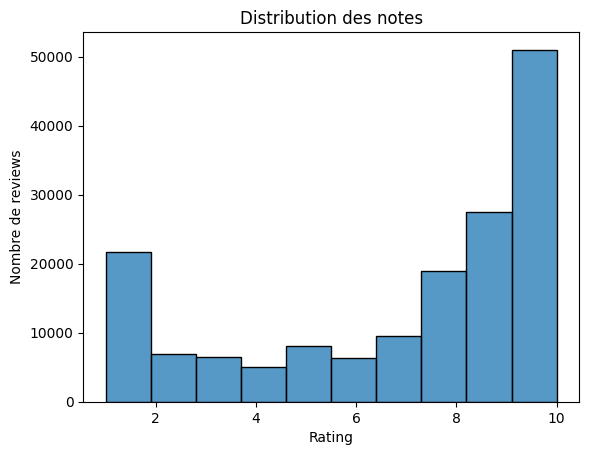

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_drug_review['rating'], bins=10, kde=False)
plt.xlabel("Rating")
plt.ylabel("Nombre de reviews")
plt.title("Distribution des notes")
plt.show()